# Spotify Lab: Vectors, Inner Products, and Similar Songs

**Name(s):**  Carlos Orellana Quintanilla

You are a new data engineer at Spotify.

When a listener asks for songs with similar content, we want to query the library of music and select appropriate recommendations. 

Every song is represented as a vector, and we are using a **vector database**: Each song is encoded as a vector of word counts. So if "love" appears 12 times in the song, the "love" coordinate is $x_{\text{love}}=12$. If Metallica writes songs about topics that are more similar to Black Sabbath than to Josh Groban, then the vector representations of their songs will have more similar profiles, and we should suggest Black Sabbath over Josh Groban. This approach is fundamental to technologies like LLMs or facial recognition, which store documents and faces as vectors and conducts fast look-ups using the kinds of math we'll look at in this lab.

The main data, `song_vectors.csv.gz`, include:

- `track_id`, `song_id`, `artist_id`: Internal unique track identifiers
- `artist_name`, `song_title`, `release`: Artist, song, album
- `release_year`, `duration`: `
- `artist_familiarity`, `artist_hotttnesss`: Measures of ubiquity, popularity
- `genre`, `top_tags`: Information about the song type
- `n_words`, `nnz_words`, `l2_norm`: Number of total words in the song, number of non-zero word coordinates (i.e. number of unique words), and the word counts squared/summed/square-rooted.
- `is_test`: Train-test split identification
- 800 columns of word counts

The `top_40_songs_by_genre.csv` file contains the top 40 songs by genre -- rock, metal, pop, punk, country, r&b/soul, folk, hip hop, electronic, blues, jazz, reggae, latin, classical -- by "hotttness". We'll use these songs to benchmark.

The `vocabulary.csv` file includes the 800 words that form the vector space in which the songs are modeled.

Each song becomes a vector of lyric-word counts, and then we use vector operations to quantify "similarity".

The big goal of this lab is simple:

**Vectors and inner products and vector length are the core tools of modern retrieval systems.**

## Setup

We will use:

- `./data/song_vectors.csv.gz`: one row per song
- `./data/vocabulary.csv`: the word columns used in the song vectors

In [130]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


songs = pd.read_csv( "./data/song_vectors.csv.gz" )
vocab = pd.read_csv( "./data/vocabulary.csv" )
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist() # Song count matrix
meta_cols = songs.columns.drop(word_cols).tolist() # Information about tracks

print('Number of songs, number of words:', songs.shape)
print( 'Song metadata fields:', meta_cols[:8])

Number of songs, number of words: (8000, 816)
Song metadata fields: ['track_id', 'song_id', 'artist_id', 'artist_name', 'song_title', 'release', 'release_year', 'duration']


In [131]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Similarity Measures for Song Vectors

The word-count columns are coordinates. That means each song is a vector in a high-dimensional space.

We will work with the song-by-word matrix $X$, where each row is one song vector.

In [132]:
X = songs[word_cols].to_numpy(dtype=float)

query_idx = 0 # Let's query the first song
query = X[query_idx]

print( 'Track metadata: \n')
print(songs.loc[query_idx, meta_cols])

print( 'Track word counts: \n')
print( query )

Track metadata: 

track_id                                            TRAAPIV128F1493132
song_id                                             SOJHKYL12A6D4FA0AC
artist_id                                           AR56P361187B9AC4DB
artist_name                                                 Gary Moore
song_title                                        What Are We Here For
release                                          Dark Days In Paradise
release_year                                                      1997
duration                                                     345.93914
artist_familiarity                                            0.761362
artist_hotttnesss                                             0.467111
genre                                                            blues
top_tags              blues; classic rock; rock; hard rock; blues rock
n_words                                                            218
nnz_words                                                  

In [133]:
# Let's see the counts for nonzero words

nonzero = np.flatnonzero(query) # return the positions of values of the array that are non-zero

pd.DataFrame({
    "word": np.array(word_cols)[nonzero], # convert the list of words to a numpy array and index it with the nonzero positions
    "count": query[nonzero].astype(int), # get the counts of the nonzero words and convert them to integers
}).sort_values("count", ascending=False).head(15)

,word,count
62,we,27
4,are,10
17,for,9
37,of,7
26,it,6
63,what,6
21,here,6
20,have,6
41,our,5
54,through,5


## Step 1: Dot Product

The dot product is our first similarity score:

$$
x \cdot y = \sum_{j=1}^m x_j y_j
$$

It gets large when two songs align count mass on the same words. 

It also tends to go up for longer songs or songs with larger total counts, which is a choice we'll have to think about.

In [134]:
# Compute the dot product between every song vector and the query vector.
dot_scores = X @ query

dot_results = songs[meta_cols].copy()
dot_results["dot"] = dot_scores
dot_results.sort_values("dot", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,dot
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2136.0
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,2115.0
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1939.0
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1680.0
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1656.0
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1654.0
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1615.0
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1476.0
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1397.0
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1383.0


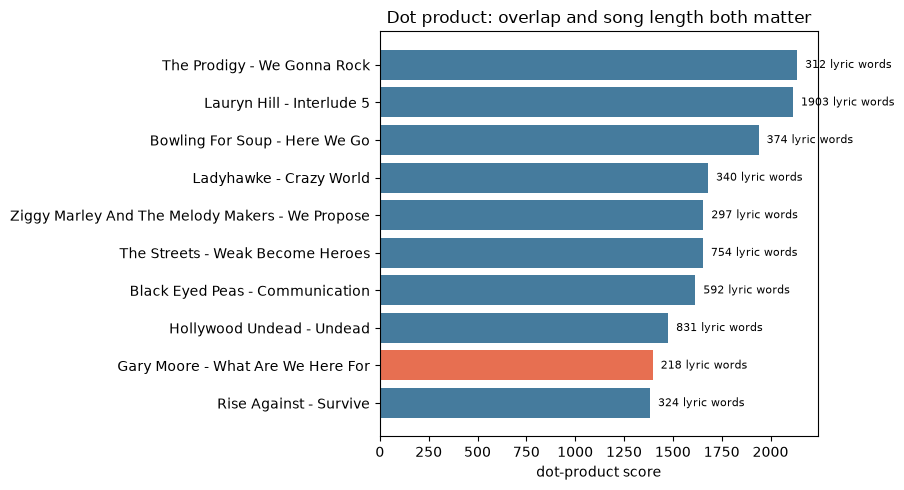

In [135]:
# Visual check: long songs can receive larger dot products.
top_dot = dot_results.sort_values("dot", ascending=False).head(10).copy()
top_dot["label"] = (
    top_dot["artist_name"].fillna("") + " - " + top_dot["song_title"].fillna("")
)
colors = ["#e76f51" if index == query_idx else "#457b9d" for index in top_dot.index]
plt.figure(figsize=(9, 5))
plt.barh(top_dot["label"], top_dot["dot"], color=colors)
for position, words in enumerate(top_dot["n_words"]):
    plt.text(top_dot["dot"].iloc[position], position, f"  {words:.0f} lyric words", va="center", fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("dot-product score")
plt.title("Dot product: overlap and song length both matter")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Look at the top matches. Do they seem similar because they use similar words, because they are genuinely similar songs, or because the dot product is partly rewarding song size?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the raw inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

The songs may look similar because songs with larger word counts tend to produce larger dot product values. This could make us think that two songs are more similar than they actually are, when the high dot product may partly be caused by large values in one or both vectors rather than genuine similarity in their word patterns.


In [136]:
def get_top_dot_matches(query_song_index, number_of_matches=3):
    query_vector = X[query_song_index]

    dot_scores = X @ query_vector

    dot_scores[query_song_index] = -np.inf

    dot_results = songs[meta_cols].copy()
    dot_results["dot"] = dot_scores

    top_matches = (
        dot_results
        .sort_values("dot", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [137]:
top_40_results = top_40.copy()
top_40_results["dot_match_1"] = ""
top_40_results["dot_match_2"] = ""
top_40_results["dot_match_3"] = ""

for top_40_index in range(len(top_40_results)):

    track_id = top_40_results.loc[top_40_index, "track_id"]

    query_song_index = songs.index[songs["track_id"] == track_id][0]

    top_matches = get_top_dot_matches(query_song_index)

    top_40_results.loc[top_40_index, "dot_match_1"] = (
        top_matches.iloc[0]["artist_name"]
        + " - "
        + top_matches.iloc[0]["song_title"]
    )

    top_40_results.loc[top_40_index, "dot_match_2"] = (
        top_matches.iloc[1]["artist_name"]
        + " - "
        + top_matches.iloc[1]["song_title"]
    )

    top_40_results.loc[top_40_index, "dot_match_3"] = (
        top_matches.iloc[2]["artist_name"]
        + " - "
        + top_matches.iloc[2]["song_title"]
    )

In [138]:
top_40_results.to_csv(
    "./data/top_40_songs_by_genre_results.csv",
    index=False
)

## Step 2: Centering and Covariance

Now we subtract each vector's own mean. This changes the question from "Do these songs use many of the same words?" to something closer to "Do these songs rise above and below their own average on the same words?"

In [139]:
query_centered = query - query.mean()
X_centered = X - X.mean(axis=1, keepdims=True)

centered_dot_scores = X_centered @ query_centered
covariance_scores = centered_dot_scores / X.shape[1]

cov_results = songs[meta_cols].copy()
cov_results["centered_dot"] = centered_dot_scores
cov_results["covariance"] = covariance_scores
cov_results.sort_values("covariance", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,centered_dot,covariance
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2064.18000,2.580225
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1856.78500,2.320981
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,1767.24000,2.209050
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1617.63000,2.022038
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1599.53625,1.999420
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1516.73875,1.895923
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1510.34125,1.887927
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1352.34875,1.690436
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1313.77875,1.642223
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1312.27875,1.640348


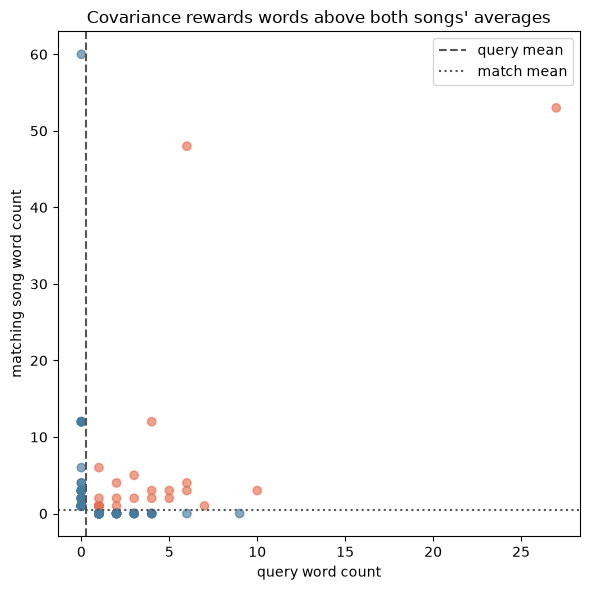

In [140]:
# Visual check: centering moves each song's average word count to zero.
comparison_idx = np.argsort(covariance_scores)[-2]
comparison = X[comparison_idx]
used_words = (query > 0) | (comparison > 0)
both_above_average = (query > query.mean()) & (comparison > comparison.mean())
plt.figure(figsize=(6, 6))
plt.scatter(query[used_words], comparison[used_words],
            c=np.where(both_above_average[used_words], "#e76f51", "#457b9d"), alpha=0.65)
plt.axvline(query.mean(), color="#555555", linestyle="--", label="query mean")
plt.axhline(comparison.mean(), color="#555555", linestyle=":", label="match mean")
plt.xlabel("query word count")
plt.ylabel("matching song word count")
plt.title("Covariance rewards words above both songs' averages")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Compare the rankings from dot product and covariance. What changed? Why does subtracting the mean change the notion of similarity?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the centered inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

Previously, we were rewarding vectors with larger word counts, which could cause them to have a larger dot product. Now, instead of only looking at which songs have the largest dot product, we center each vector and look at whether the word counts are above or below each song’s average. This gives us a cleaner way to compare the pattern of word usage between songs.


In [141]:
def get_top_centered_matches(query_song_index, number_of_matches=3):
    query_vector = X[query_song_index]
    query_centered = query_vector - query_vector.mean()

    centered_dot_scores = X_centered @ query_centered

    centered_dot_scores[query_song_index] = -np.inf

    centered_results = songs[meta_cols].copy()
    centered_results["centered_dot"] = centered_dot_scores

    top_matches = (
        centered_results
        .sort_values("centered_dot", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [142]:
top_40_results["centered_match_1"] = ""
top_40_results["centered_match_2"] = ""
top_40_results["centered_match_3"] = ""

for top_40_index in range(len(top_40_results)):

    track_id = top_40_results.loc[top_40_index, "track_id"]

    query_song_index = songs.index[
        songs["track_id"] == track_id
    ][0]

    top_matches = get_top_centered_matches(query_song_index)

    top_40_results.loc[top_40_index, "centered_match_1"] = (
        top_matches.iloc[0]["artist_name"]
        + " - "
        + top_matches.iloc[0]["song_title"]
    )

    top_40_results.loc[top_40_index, "centered_match_2"] = (
        top_matches.iloc[1]["artist_name"]
        + " - "
        + top_matches.iloc[1]["song_title"]
    )

    top_40_results.loc[top_40_index, "centered_match_3"] = (
        top_matches.iloc[2]["artist_name"]
        + " - "
        + top_matches.iloc[2]["song_title"]
    )

In [143]:
top_40_results.to_csv(
    "./data/top_40_songs_by_genre_results.csv",
    index=False
)

## Step 3: Correlation

Correlation takes covariance and rescales by each vector's standard deviation. That means we now compare shared pattern after accounting for both average level and spread.

In [144]:
query_std = query.std()
X_std = X.std(axis=1)

denom = X_std * query_std
corr_scores = np.divide(
    covariance_scores,
    denom,
    out=np.zeros_like(covariance_scores),
    where=denom != 0,
)

corr_results = songs[meta_cols].copy()
corr_results["correlation"] = corr_scores
corr_results.sort_values("correlation", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,correlation
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1.000000
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,0.755614
4677,TROCPYO128F92F9ADC,SOVVPIM12AF72A33E8,AR6097P1187B998E3E,Modern Life Is War,Destination: Death or Better Days,My Love My Way,2006,148.29669,0.647507,0.480729,metal,metalcore; addicting; fury music,204,112,28.301943,0,0.746012
4933,TRYTJTL128F92D1345,SOWNBCM12A8C141160,ARWDDHA1187FB3A745,EDGUY,Superheroes,Fucking With Fire - Live,2005,242.54649,0.722370,0.526279,metal,Power metal; metal; heavy metal; edguy; melodi...,191,75,39.268308,0,0.728089
4521,TRHYEBV12903CE8274,SOHVDHF12AC4685D1D,ARBC4CV1187B9A7823,Lifetime,Daneurysm,Hello Bastards,1995,71.15710,0.714125,0.539633,metal,hardcore; energy; fast; punk; free download,68,32,14.456832,0,0.698025
4489,TRGPMNN128F428B362,SOSAYAA12A8C1393FA,AR6RSHA1187FB3F03F,Raised Fist,Soldiers Of Today,Watch Your Step,1996,152.63302,0.694461,0.457958,metal,hardcore punk,222,95,28.478062,0,0.696568
4550,TRJDFLG128F934B261,SOSLMFL12A8C130DC5,ARK358A1187B9ADDC0,Tourniquet,Convoluted Absolutes,Where Moth And Rust Destroy,2003,337.03138,0.584310,0.398297,metal,metal; Power metal; Progressive metal; heavy m...,189,92,23.194827,0,0.684930
5831,TRLZCAQ128F424D4E4,SOYNGQB12A6D4FD387,AR01SCU1187B9A693C,Street Dogs,Free,State of Grace,2008,219.87220,0.683245,0.486471,punk,irish; Ballad; celtic punk; candidate,291,121,37.349699,0,0.684267
4896,TRXAMNT12903CF43BE,SOSHOZQ12AB017C3B2,ARVXKTV1187FB44139,Arsonists Get All The Girls,Tourtasia,The Game Of Life,2007,227.42159,0.725403,0.454957,metal,deathcore; experimental; grindcore; mathcore; ...,195,118,22.847319,0,0.679579
5184,TRJOQXR128F92EB51A,SOXKDWF12AB017BF6F,ARWSN471187B9A6F7F,Thompson Twins,We Are Detective,Quick Step And Side Kick,1983,182.98730,0.648702,0.441576,pop,80s; new wave; pop; 1980s; alternative,172,91,28.035692,0,0.678728


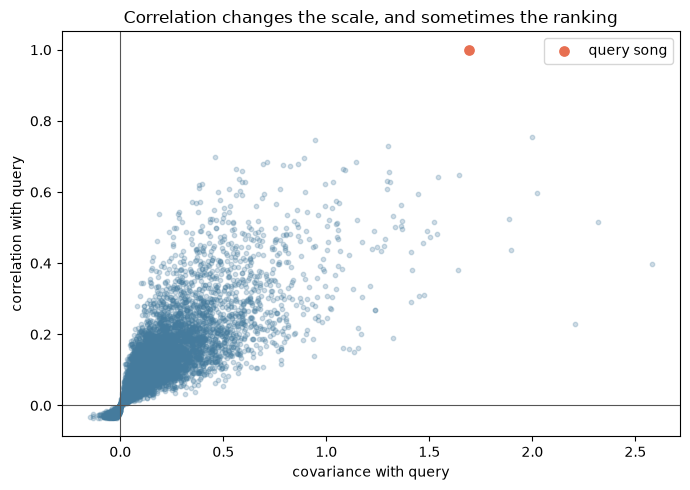

In [145]:
# Visual check: correlation rescales covariance by each song's spread.
plt.figure(figsize=(7, 5))
plt.scatter(covariance_scores, corr_scores, s=10, alpha=0.25, color="#457b9d")
plt.axhline(0, color="#555555", linewidth=0.8)
plt.axvline(0, color="#555555", linewidth=0.8)
plt.scatter(covariance_scores[query_idx], corr_scores[query_idx], color="#e76f51", s=45, label="query song")
plt.xlabel("covariance with query")
plt.ylabel("correlation with query")
plt.title("Correlation changes the scale, and sometimes the ranking")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Correlation and covariance are related, but not identical. What kind of song might move up in the ranking after standardization? What kind might move down?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the correlation. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

Covariance identifies a shared pattern, but songs can have the same pattern with very different spreads. This difference in spread can affect their covariance scores and rankings. Correlation standardizes the scores by accounting for each song’s spread, giving us a fairer comparison of the actual pattern. Because of this, some songs may move up or down in the ranking.

In [146]:
def get_top_correlation_matches(query_song_index, number_of_matches=3):
    query_vector = X[query_song_index]

    query_centered = query_vector - query_vector.mean()
    centered_dot_scores = X_centered @ query_centered

    covariance_scores = centered_dot_scores / X.shape[1]

    query_std = query_vector.std()
    denominator = X_std * query_std

    correlation_scores = np.divide(
        covariance_scores,
        denominator,
        out=np.zeros_like(covariance_scores),
        where=denominator != 0,
    )

    correlation_scores[query_song_index] = -np.inf

    correlation_results = songs[meta_cols].copy()
    correlation_results["correlation"] = correlation_scores

    top_matches = (
        correlation_results
        .sort_values("correlation", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [147]:
top_40_results["correlation_match_1"] = ""
top_40_results["correlation_match_2"] = ""
top_40_results["correlation_match_3"] = ""

for top_40_index in range(len(top_40_results)):

    track_id = top_40_results.loc[top_40_index, "track_id"]

    query_song_index = songs.index[
        songs["track_id"] == track_id
    ][0]

    top_matches = get_top_correlation_matches(query_song_index)

    top_40_results.loc[top_40_index, "correlation_match_1"] = (
        top_matches.iloc[0]["artist_name"]
        + " - "
        + top_matches.iloc[0]["song_title"]
    )

    top_40_results.loc[top_40_index, "correlation_match_2"] = (
        top_matches.iloc[1]["artist_name"]
        + " - "
        + top_matches.iloc[1]["song_title"]
    )

    top_40_results.loc[top_40_index, "correlation_match_3"] = (
        top_matches.iloc[2]["artist_name"]
        + " - "
        + top_matches.iloc[2]["song_title"]
    )

In [148]:
top_40_results.to_csv(
    "./data/top_40_songs_by_genre_results.csv",
    index=False
)

## Step 4: Cosine Similarity

Cosine similarity compares the raw vectors without centering around their means:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

In retrieval systems, this is often a better measure of content similarity than the raw dot product.

In [149]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )


cos_scores = cosine_scores(X, query)

cosine_results = songs[meta_cols].copy()
cosine_results["cosine"] = cos_scores
cosine_results.sort_values("cosine", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,cosine
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1.000000
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,0.761523
4677,TROCPYO128F92F9ADC,SOVVPIM12AF72A33E8,AR6097P1187B998E3E,Modern Life Is War,Destination: Death or Better Days,My Love My Way,2006,148.29669,0.647507,0.480729,metal,metalcore; addicting; fury music,204,112,28.301943,0,0.755322
4933,TRYTJTL128F92D1345,SOWNBCM12A8C141160,ARWDDHA1187FB3A745,EDGUY,Superheroes,Fucking With Fire - Live,2005,242.54649,0.722370,0.526279,metal,Power metal; metal; heavy metal; edguy; melodi...,191,75,39.268308,0,0.735159
4489,TRGPMNN128F428B362,SOSAYAA12A8C1393FA,AR6RSHA1187FB3F03F,Raised Fist,Soldiers Of Today,Watch Your Step,1996,152.63302,0.694461,0.457958,metal,hardcore punk,222,95,28.478062,0,0.707435
4521,TRHYEBV12903CE8274,SOHVDHF12AC4685D1D,ARBC4CV1187B9A7823,Lifetime,Daneurysm,Hello Bastards,1995,71.15710,0.714125,0.539633,metal,hardcore; energy; fast; punk; free download,68,32,14.456832,0,0.703254
4550,TRJDFLG128F934B261,SOSLMFL12A8C130DC5,ARK358A1187B9ADDC0,Tourniquet,Convoluted Absolutes,Where Moth And Rust Destroy,2003,337.03138,0.584310,0.398297,metal,metal; Power metal; Progressive metal; heavy m...,189,92,23.194827,0,0.696703
5831,TRLZCAQ128F424D4E4,SOYNGQB12A6D4FD387,AR01SCU1187B9A693C,Street Dogs,Free,State of Grace,2008,219.87220,0.683245,0.486471,punk,irish; Ballad; celtic punk; candidate,291,121,37.349699,0,0.696275
4896,TRXAMNT12903CF43BE,SOSHOZQ12AB017C3B2,ARVXKTV1187FB44139,Arsonists Get All The Girls,Tourtasia,The Game Of Life,2007,227.42159,0.725403,0.454957,metal,deathcore; experimental; grindcore; mathcore; ...,195,118,22.847319,0,0.692076
5184,TRJOQXR128F92EB51A,SOXKDWF12AB017BF6F,ARWSN471187B9A6F7F,Thompson Twins,We Are Detective,Quick Step And Side Kick,1983,182.98730,0.648702,0.441576,pop,80s; new wave; pop; 1980s; alternative,172,91,28.035692,0,0.689013


<div class="alert alert-block alert-warning">

Compare the dot-product ranking to the cosine-similarity ranking. Which one seems more like a "similar songs" engine and which one seems more like a "shares lots of raw word mass" engine?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using cosine similarity. Before sorting, set the query song's score to `-np.inf`. Save your results as another column in "./data/top_40_songs_by_genre_results.csv".

</div>

Previously, when we used the dot product, songs with larger word counts could produce larger dot product values, which could cause them to be ranked as more similar because of the size of their vectors. With cosine similarity, we account for the magnitude of the vectors and focus more on their direction. This means we are looking at whether the songs have similar patterns or proportions of word usage rather than just large word counts. Because of this, cosine similarity seems to me more like a "similar songs" engine, while the dot product is more like a "shares lots of raw word mass" engine.


In [150]:
def get_top_cosine_matches(query_song_index, number_of_matches=3):
    query_vector = X[query_song_index]

    cosine_similarity_scores = cosine_scores(X, query_vector)

    cosine_similarity_scores[query_song_index] = -np.inf

    cosine_results = songs[meta_cols].copy()
    cosine_results["cosine"] = cosine_similarity_scores

    top_matches = (
        cosine_results
        .sort_values("cosine", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [151]:
top_40_results["cosine_match_1"] = ""
top_40_results["cosine_match_2"] = ""
top_40_results["cosine_match_3"] = ""

for top_40_index in range(len(top_40_results)):

    track_id = top_40_results.loc[top_40_index, "track_id"]

    query_song_index = songs.index[
        songs["track_id"] == track_id
    ][0]

    top_matches = get_top_cosine_matches(query_song_index)

    top_40_results.loc[top_40_index, "cosine_match_1"] = (
        top_matches.iloc[0]["artist_name"]
        + " - "
        + top_matches.iloc[0]["song_title"]
    )

    top_40_results.loc[top_40_index, "cosine_match_2"] = (
        top_matches.iloc[1]["artist_name"]
        + " - "
        + top_matches.iloc[1]["song_title"]
    )

    top_40_results.loc[top_40_index, "cosine_match_3"] = (
        top_matches.iloc[2]["artist_name"]
        + " - "
        + top_matches.iloc[2]["song_title"]
    )

In [152]:
top_40_results.to_csv(
    "./data/top_40_songs_by_genre_results.csv",
    index=False
)

<div class="alert alert-block alert-warning">

For the Top 40 songs, do you notice any patterns across the inner product, correlation, and cosine similarity top three recommendations you provided? Is there significant agreement, or do the recommendations change significantly by method?

Which methods are most in agreement?

Which methods do you think give the best results?

</div>

The pattern I noticed is that the inner product tends to reward vectors with larger values and correlation and cosine are less influenced by the overall size of the vectors. 

Correlation is more on whether the two vectors follow a similar pattern base on their averages and cosine is on whether the raw vectors point in a similar direction. This may explain why correlation and cosine similarity produce more similar recommendations than the inner product.


Which methods are most in agreement?

Correlation and cosine similarity are the methods that agree the most. They tends to recommend the same three songs. 

Which methods do you think give the best results?

I think the correlation and cosine similarity methods give the best results. the inner product tends to recommend the same songs across many different song titles, which indicates that something may be causing those songs to repeatedly receive high scores. For example, "Interlude 5" by Lauryn Hill has 1,903 words and "B-Boy Bouillabaisse: A.W.O.L." by the Beastie Boys has 1,746 words, and both repeatedly appeared in the inner product recommendations. Their large word counts could be contributing to their high dot product scores.

In comparison, songs recommended by correlation and cosine similarity can have much smaller word counts. For example, "You're All The World To Me" by Tony Bennett has 145 words and "Plastic World" by Naked Aggression has 282 words. This suggests that the correlation and cosine similarity recommendations are less influenced by total word count and are instead focusing more on the pattern or direction of word usage. For this reason, I think these methods provide better results for finding similar songs.

In [153]:
results = pd.read_csv("./data/top_40_songs_by_genre_results.csv")

results[
    [
        "artist_name",
        "song_title",
        "dot_match_1",
        "dot_match_2",
        "dot_match_3",
        "correlation_match_1",
        "correlation_match_2",
        "correlation_match_3",
        "cosine_match_1",
        "cosine_match_2",
        "cosine_match_3",
    ]
].head(10)

,artist_name,song_title,dot_match_1,dot_match_2,dot_match_3,correlation_match_1,correlation_match_2,correlation_match_3,cosine_match_1,cosine_match_2,cosine_match_3
0,Michael Jackson,All The Things You Are,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Katy Perry - Hot N Cold (Innerpartysystem Main),Tony Bennett - You're All The World To Me,Patricia Barber - You're The Top,Husker Du - You're A Soldier,Tony Bennett - You're All The World To Me,Patricia Barber - You're The Top,Husker Du - You're A Soldier
1,John Mayer,Vultures,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Lauryn Hill - Interlude 5,R. Kelly - I Mean (I Don't Mean It),Naked Aggression - Plastic World,Ozma - The Ups And Downs,Sage Francis - Keep Moving,Naked Aggression - Plastic World,Ozma - The Ups And Downs,Sage Francis - Keep Moving
2,John Mayer,Out Of My Mind,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Fat Joe - Preacher On A Sunday Morning,Calvin Harris - Ready For The Weekend,KATAKLYSM - Beyond Salvation,Fat Joe - Preacher On A Sunday Morning,Calvin Harris - Ready For The Weekend,KATAKLYSM - Beyond Salvation
3,R. Kelly,Hump Bounce,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Erykah Badu - I Want You,The Derek Trucks Band - All I Do,Avalon - Overjoyed,Billie Piper - Day And Night,The Derek Trucks Band - All I Do,Avalon - Overjoyed,Billie Piper - Day And Night
4,R. Kelly,Intro - The Sermon,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Blues Traveler - Hook,G-Unit - I Don't Want To Talk About It,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Blues Traveler - Hook,G-Unit - I Don't Want To Talk About It
5,Michael Jackson,Call On Me,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Albert Hammond Jr - G Up,Anastacia - Club Megamix,Blues Traveler - Hook,Albert Hammond Jr - G Up,Anastacia - Club Megamix,Blues Traveler - Hook
6,The Black Keys,Oceans and Streams,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Eminem - 8 Mile,Manafest - Runaway,The Cat Empire - The Car Song,Ballboy - I Don't Have Time To Stand Here With...,Manafest - Runaway,The Cat Empire - The Car Song,Ballboy - I Don't Have Time To Stand Here With...
7,The Black Keys,10 A.M. Automatic,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Michael Jackson - Man In The Mirror,Warrant - Bad Tattoo,Doyle Bramhall - Dimples,Ayo - Only You,Warrant - Bad Tattoo,Doyle Bramhall - Dimples,Ayo - Only You
8,The Black Keys,Aeroplane Blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,R. Kelly - I Mean (I Don't Mean It),Johnny Cash - I Don't Know Where I'm Bound,LMFAO - I Am Not A Whore,Sneaky Sound System - 16,Johnny Cash - I Don't Know Where I'm Bound,LMFAO - I Am Not A Whore,Sneaky Sound System - 16
9,The Black Keys,All Hands Against His Own,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Michael Jackson - Man In The Mirror,Brandy - Give Me You,Leonard Cohen - The Stranger Song,Athlete - New Project,Leonard Cohen - The Stranger Song,Brandy - Give Me You,Athlete - New Project


In [154]:
songs.loc[
    (
        (songs["artist_name"] == "Lauryn Hill") &
        (songs["song_title"] == "Interlude 5")
    ) |
    (
        (songs["artist_name"] == "Beastie Boys") &
        (songs["song_title"].str.contains("B-Boy Bouillabaisse", na=False))
    ),
    ["artist_name", "song_title", "n_words"]
]

,artist_name,song_title,n_words
2691,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,1746
6290,Lauryn Hill,Interlude 5,1903


In [155]:
songs.loc[
    (
        (songs["artist_name"] == "Tony Bennett") &
        (songs["song_title"] == "You're All The World To Me")
    ) |
    (
        (songs["artist_name"] == "Naked Aggression") &
        (songs["song_title"] == "Plastic World")
    ),
    ["artist_name", "song_title", "n_words"]
]

,artist_name,song_title,n_words
3583,Tony Bennett,You're All The World To Me,145
5625,Naked Aggression,Plastic World,282


## Step 5:

Some words are "outliers": They appear in many songs with overwhelming frequency. For example, "love" is a common word in songs. That will boost the inner product significantly. Conversely, rare words like "amortization" or "zebra" might be rare and important for matching, but receive the same weight as a generic word like "about".

There is a useful technology to deal with this. We're going to cover one way of implementing it.

- Step 1: Compute the **term frequency** of each song-word pair, by taking $\log(1+x_{song,word})$. This is a matrix, $TF$. This transformation reduces the marginal importance of common words.
- Step 2: Compute the **inverse document frequency** of each word. Let $N$ be the number of documents. Let $df_w$ be the document frequency of word $w$, the num of documents in which word $w$ appears. Then $IDF_w = \log( N / df_w)$.

The **TF-IDF** matrix reweights the $TF$ matrix by the $IDF$ vector: $TFIDF = TF 	imes IDF$. This transformed matrix is then used for retrieval calculations (raw inner product, centered inner product, correlation, cosine similarity), instead of the raw word counts.

In [156]:
# Term frequency: repeated uses of one word count less and less.
TF = np.log1p(X) # Compute TF

# Document frequency: how many songs use each word at least once.
N = X.shape[0] # Determine number of documents
df = (X > 0).sum(axis=0) # Compute document frequency
IDF = np.log(N / df) # Compute IDF

# IDF is one number per word, so NumPy broadcasts it across every song row.
TFIDF = TF * IDF

print(pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=True).head(10))

print( pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=False).head(10) )

     word  document_frequency       idf
324     i                5966  0.293365
22    and                5960  0.294371
795   you                5671  0.344076
409    me                5420  0.389346
331    in                5345  0.403280
334    is                5191  0.432515
336    it                5045  0.461044
466   not                4961  0.477834
475    of                4785  0.513956
662  that                4597  0.554038
     word  document_frequency       idf
176   doo                  26  5.729100
258  funk                  48  5.115996
726   ven                  56  4.961845
327   ihr                  59  4.909659
770   wir                  60  4.892852
201    er                  63  4.844062
711     u                  66  4.797542
162  dich                  68  4.767689
596   sie                  78  4.630488
208    eu                  81  4.592748


<div class="alert alert-block alert-warning">

Do you notice any patterns among the lowest and highest IDF words?

Rerun your results from the previous steps to use raw inner product, centered inner product, correlation, and cosine similarity to generate new top 3 **non-self** recommendations for the top 40 songs.

How do the new TF-IDF-based recommendations compare to one another and the original recommendations?


</div>

The pattern I noticed is that common words tend to have lower IDF values, while rarer words tend to have higher IDF values.

We got some new results after applying TF-IDF, which I think is expected because we are now giving more weight to rare words and less weight to common words instead of relying mainly on their counts. Correlation and cosine similarity still seem to follow a similar pattern as before, and the inner product also seems to behave somewhat similarly to its previous results. The main difference is that TF-IDF changes the importance of the words being used in the comparisons, which results in some different song recommendations. I think the next step would be to actually listen to some of the recommended songs and see whether they seem like good recommendations :)

In [ ]:
TFIDF_centered = TFIDF - TFIDF.mean(axis=1, keepdims=True)
TFIDF_std = TFIDF.std(axis=1)


In [158]:
def get_top_tfidf_dot_matches(query_song_index, number_of_matches=3):
    query_vector = TFIDF[query_song_index]

    dot_scores = TFIDF @ query_vector

    dot_scores[query_song_index] = -np.inf

    dot_results = songs[meta_cols].copy()
    dot_results["tfidf_dot"] = dot_scores

    top_matches = (
        dot_results
        .sort_values("tfidf_dot", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [159]:
def get_top_tfidf_centered_matches(query_song_index, number_of_matches=3):
    query_vector = TFIDF[query_song_index]
    query_centered = query_vector - query_vector.mean()

    centered_dot_scores = TFIDF_centered @ query_centered

    centered_dot_scores[query_song_index] = -np.inf

    centered_results = songs[meta_cols].copy()
    centered_results["tfidf_centered_dot"] = centered_dot_scores

    top_matches = (
        centered_results
        .sort_values("tfidf_centered_dot", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [160]:
def get_top_tfidf_correlation_matches(query_song_index, number_of_matches=3):
    query_vector = TFIDF[query_song_index]

    query_centered = query_vector - query_vector.mean()

    centered_dot_scores = TFIDF_centered @ query_centered

    covariance_scores = centered_dot_scores / TFIDF.shape[1]

    query_std = query_vector.std()

    denominator = TFIDF_std * query_std

    correlation_scores = np.divide(
        covariance_scores,
        denominator,
        out=np.zeros_like(covariance_scores),
        where=denominator != 0,
    )

    correlation_scores[query_song_index] = -np.inf

    correlation_results = songs[meta_cols].copy()
    correlation_results["tfidf_correlation"] = correlation_scores

    top_matches = (
        correlation_results
        .sort_values("tfidf_correlation", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [161]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector

    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)

    denominators = matrix_norms * query_norm

    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )

In [162]:
def get_top_tfidf_cosine_matches(query_song_index, number_of_matches=3):
    query_vector = TFIDF[query_song_index]

    cosine_similarity_scores = cosine_scores(
        TFIDF,
        query_vector
    )

    cosine_similarity_scores[query_song_index] = -np.inf

    cosine_results = songs[meta_cols].copy()
    cosine_results["tfidf_cosine"] = cosine_similarity_scores

    top_matches = (
        cosine_results
        .sort_values("tfidf_cosine", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [163]:
top_40_results["tfidf_dot_match_1"] = ""
top_40_results["tfidf_dot_match_2"] = ""
top_40_results["tfidf_dot_match_3"] = ""

top_40_results["tfidf_centered_match_1"] = ""
top_40_results["tfidf_centered_match_2"] = ""
top_40_results["tfidf_centered_match_3"] = ""

top_40_results["tfidf_correlation_match_1"] = ""
top_40_results["tfidf_correlation_match_2"] = ""
top_40_results["tfidf_correlation_match_3"] = ""

top_40_results["tfidf_cosine_match_1"] = ""
top_40_results["tfidf_cosine_match_2"] = ""
top_40_results["tfidf_cosine_match_3"] = ""

In [164]:
for top_40_index in range(len(top_40_results)):

    track_id = top_40_results.loc[top_40_index, "track_id"]

    query_song_index = songs.index[
        songs["track_id"] == track_id
    ][0]

    dot_matches = get_top_tfidf_dot_matches(query_song_index)

    top_40_results.loc[top_40_index, "tfidf_dot_match_1"] = (
        dot_matches.iloc[0]["artist_name"]
        + " - "
        + dot_matches.iloc[0]["song_title"]
    )

    top_40_results.loc[top_40_index, "tfidf_dot_match_2"] = (
        dot_matches.iloc[1]["artist_name"]
        + " - "
        + dot_matches.iloc[1]["song_title"]
    )

    top_40_results.loc[top_40_index, "tfidf_dot_match_3"] = (
        dot_matches.iloc[2]["artist_name"]
        + " - "
        + dot_matches.iloc[2]["song_title"]
    )

    centered_matches = get_top_tfidf_centered_matches(query_song_index)

    top_40_results.loc[top_40_index, "tfidf_centered_match_1"] = (
        centered_matches.iloc[0]["artist_name"]
        + " - "
        + centered_matches.iloc[0]["song_title"]
    )

    top_40_results.loc[top_40_index, "tfidf_centered_match_2"] = (
        centered_matches.iloc[1]["artist_name"]
        + " - "
        + centered_matches.iloc[1]["song_title"]
    )

    top_40_results.loc[top_40_index, "tfidf_centered_match_3"] = (
        centered_matches.iloc[2]["artist_name"]
        + " - "
        + centered_matches.iloc[2]["song_title"]
    )

    correlation_matches = get_top_tfidf_correlation_matches(query_song_index)

    top_40_results.loc[top_40_index, "tfidf_correlation_match_1"] = (
        correlation_matches.iloc[0]["artist_name"]
        + " - "
        + correlation_matches.iloc[0]["song_title"]
    )

    top_40_results.loc[top_40_index, "tfidf_correlation_match_2"] = (
        correlation_matches.iloc[1]["artist_name"]
        + " - "
        + correlation_matches.iloc[1]["song_title"]
    )

    top_40_results.loc[top_40_index, "tfidf_correlation_match_3"] = (
        correlation_matches.iloc[2]["artist_name"]
        + " - "
        + correlation_matches.iloc[2]["song_title"]
    )

    cosine_matches = get_top_tfidf_cosine_matches(query_song_index)

    top_40_results.loc[top_40_index, "tfidf_cosine_match_1"] = (
        cosine_matches.iloc[0]["artist_name"]
        + " - "
        + cosine_matches.iloc[0]["song_title"]
    )

    top_40_results.loc[top_40_index, "tfidf_cosine_match_2"] = (
        cosine_matches.iloc[1]["artist_name"]
        + " - "
        + cosine_matches.iloc[1]["song_title"]
    )

    top_40_results.loc[top_40_index, "tfidf_cosine_match_3"] = (
        cosine_matches.iloc[2]["artist_name"]
        + " - "
        + cosine_matches.iloc[2]["song_title"]
    )

In [165]:
top_40_results.to_csv(
    "./data/top_40_songs_by_genre_results.csv",
    index=False
)

In [166]:
columns_to_show = [
    "artist_name",
    "song_title",

    "dot_match_1",
    "dot_match_2",
    "dot_match_3",

    "correlation_match_1",
    "correlation_match_2",
    "correlation_match_3",

    "cosine_match_1",
    "cosine_match_2",
    "cosine_match_3",

    "tfidf_dot_match_1",
    "tfidf_dot_match_2",
    "tfidf_dot_match_3",

    "tfidf_correlation_match_1",
    "tfidf_correlation_match_2",
    "tfidf_correlation_match_3",

    "tfidf_cosine_match_1",
    "tfidf_cosine_match_2",
    "tfidf_cosine_match_3",
]

top_40_results[columns_to_show].head(3)

,artist_name,song_title,dot_match_1,dot_match_2,dot_match_3,correlation_match_1,correlation_match_2,correlation_match_3,cosine_match_1,cosine_match_2,cosine_match_3,tfidf_dot_match_1,tfidf_dot_match_2,tfidf_dot_match_3,tfidf_correlation_match_1,tfidf_correlation_match_2,tfidf_correlation_match_3,tfidf_cosine_match_1,tfidf_cosine_match_2,tfidf_cosine_match_3
0,Michael Jackson,All The Things You Are,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Katy Perry - Hot N Cold (Innerpartysystem Main),Tony Bennett - You're All The World To Me,Patricia Barber - You're The Top,Husker Du - You're A Soldier,Tony Bennett - You're All The World To Me,Patricia Barber - You're The Top,Husker Du - You're A Soldier,Aqua - Happy Boys & Girls,Flipsyde - Angel,Cathy Dennis - Being With You,Colin James - These Arms Of Mine,Big Bad Voodoo Daddy - Please Baby,Michael Jackson - Baby Be Mine,Colin James - These Arms Of Mine,Big Bad Voodoo Daddy - Please Baby,Michael Jackson - Baby Be Mine
1,John Mayer,Vultures,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Lauryn Hill - Interlude 5,R. Kelly - I Mean (I Don't Mean It),Naked Aggression - Plastic World,Ozma - The Ups And Downs,Sage Francis - Keep Moving,Naked Aggression - Plastic World,Ozma - The Ups And Downs,Sage Francis - Keep Moving,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Binary Star - Honest Expression,Barry White - Never Gonna Give You Up,Matisyahu - Fire and Heights,Matisyahu - Jerusalem,Matisyahu - Fire and Heights,Barry White - Never Gonna Give You Up,Matisyahu - Jerusalem
2,John Mayer,Out Of My Mind,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Fat Joe - Preacher On A Sunday Morning,Calvin Harris - Ready For The Weekend,KATAKLYSM - Beyond Salvation,Fat Joe - Preacher On A Sunday Morning,Calvin Harris - Ready For The Weekend,KATAKLYSM - Beyond Salvation,Lauryn Hill - Interlude 5,Eminem - If I Had,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Heatmiser - Half Right,Pop Levi - Hades Lady,Camper Van Beethoven - Sad Lover's Waltz,Heatmiser - Half Right,Eminem - If I Had,Gary Allan - Half Of My Mistakes


## Part 2: Evaluate a Genre Retrieval System

To engineer a system, we need a ground truth for success or failure. In practice, we would have experts label a dataset or observe user responses and infer success or failure (success might mean they continue their session and click on one of our recommendations, and failure means their session continues but they search for new songs on their own). In the absence of a ground truth, we can use the song genre.

So your job is:

1. For every Top-40 query song, remove the query song itself and every song by the same artist before selecting the top three recommendations for raw inner product, cosine similarity, and TF-IDF-based cosine similarity. If a recommendation's genre matches the query song's genre, record a hit (`True`); otherwise record a miss (`False`). Report `hits.mean()`: this is mean **precision@3**, the share of all recommendation slots that are same-genre hits. Do not hard-code the denominator.
2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.
3. Write up your results in a separate text file, as a report on your work as a data engineer. Do the existing options work well, or did you find ways to outperform it?


1. For every Top-40 query song, remove the query song itself and every song by the same artist before selecting the top three recommendations for raw inner product, cosine similarity, and TF-IDF-based cosine similarity. If a recommendation's genre matches the query song's genre, record a hit (`True`); otherwise record a miss (`False`). Report `hits.mean()`: this is mean **precision@3**, the share of all recommendation slots that are same-genre hits. Do not hard-code the denominator.

In [167]:
query_song_index = 0

query_artist = songs.loc[query_song_index, "artist_name"]

different_artist = songs["artist_name"] != query_artist
not_query_song = songs.index != query_song_index

valid_songs = different_artist & not_query_song

songs.loc[valid_songs, ["artist_name", "song_title"]].head(3)

,artist_name,song_title
1,Sandi Thom,Wounded Hearts
2,G. Love & Special Sauce,Willow Tree
3,Willie Dixon,That's My Baby


In [168]:
def get_top_dot_matches(query_song_index, valid_songs, number_of_matches=3):
    query_vector = X[query_song_index]

    dot_scores = X @ query_vector

    dot_scores[~valid_songs] = -np.inf

    dot_results = songs[meta_cols].copy()
    dot_results["dot"] = dot_scores

    top_matches = (
        dot_results
        .sort_values("dot", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [169]:
def get_top_cosine_matches(query_song_index, valid_songs, number_of_matches=3):
    query_vector = X[query_song_index]

    cosine_similarity_scores = cosine_scores(
        X,
        query_vector
    )

    cosine_similarity_scores[~valid_songs] = -np.inf

    cosine_results = songs[meta_cols].copy()
    cosine_results["cosine"] = cosine_similarity_scores

    top_matches = (
        cosine_results
        .sort_values("cosine", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [170]:
def get_top_tfidf_cosine_matches(query_song_index, valid_songs, number_of_matches=3):
    query_vector = TFIDF[query_song_index]

    tfidf_cosine_scores = cosine_scores(
        TFIDF,
        query_vector
    )

    tfidf_cosine_scores[~valid_songs] = -np.inf

    tfidf_cosine_results = songs[meta_cols].copy()
    tfidf_cosine_results["tfidf_cosine"] = tfidf_cosine_scores

    top_matches = (
        tfidf_cosine_results
        .sort_values("tfidf_cosine", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [171]:
dot_hits = []
cosine_hits = []
tfidf_cosine_hits = []

for top_40_index in range(len(top_40)):

    track_id = top_40.loc[top_40_index, "track_id"]

    query_song_index = songs.index[
        songs["track_id"] == track_id
    ][0]

    query_artist = songs.loc[query_song_index, "artist_name"]
    query_genre = songs.loc[query_song_index, "genre"]

    different_artist = songs["artist_name"] != query_artist
    not_query_song = songs.index != query_song_index

    valid_songs = different_artist & not_query_song


    top_dot_matches = get_top_dot_matches(
        query_song_index,
        valid_songs
    )

    top_cosine_matches = get_top_cosine_matches(
        query_song_index,
        valid_songs
    )

    top_tfidf_cosine_matches = get_top_tfidf_cosine_matches(
        query_song_index,
        valid_songs
    )


    dot_hits.extend(
        top_dot_matches["genre"] == query_genre
    )

    cosine_hits.extend(
        top_cosine_matches["genre"] == query_genre
    )

    tfidf_cosine_hits.extend(
        top_tfidf_cosine_matches["genre"] == query_genre
    )

In [172]:
dot_hits = np.array(dot_hits)
cosine_hits = np.array(cosine_hits)
tfidf_cosine_hits = np.array(tfidf_cosine_hits)

print("Raw inner product hits:", dot_hits.mean())
print("Cosine similarity hits:", cosine_hits.mean())
print("TF-IDF cosine hits:", tfidf_cosine_hits.mean())

Raw inner product hits: 0.09285714285714286
Cosine similarity hits: 0.19107142857142856
TF-IDF cosine hits: 0.21071428571428572


2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.

In [173]:
X_centered = X - X.mean(axis=1, keepdims=True)
X_std = X.std(axis=1)

TFIDF_centered = TFIDF - TFIDF.mean(axis=1, keepdims=True)
TFIDF_std = TFIDF.std(axis=1)

In [174]:
def get_top_correlation_matches(
    query_song_index,
    valid_songs,
    number_of_matches=3
):
    query_vector = X[query_song_index]

    query_centered = query_vector - query_vector.mean()

    centered_dot_scores = X_centered @ query_centered

    covariance_scores = centered_dot_scores / X.shape[1]

    query_std = query_vector.std()
    denominator = X_std * query_std

    correlation_scores = np.divide(
        covariance_scores,
        denominator,
        out=np.zeros_like(covariance_scores),
        where=denominator != 0,
    )

    correlation_scores[~valid_songs] = -np.inf

    correlation_results = songs[meta_cols].copy()
    correlation_results["correlation"] = correlation_scores

    top_matches = (
        correlation_results
        .sort_values("correlation", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [175]:
def get_top_tfidf_correlation_matches(
    query_song_index,
    valid_songs,
    number_of_matches=3
):
    query_vector = TFIDF[query_song_index]

    query_centered = query_vector - query_vector.mean()

    centered_dot_scores = TFIDF_centered @ query_centered

    covariance_scores = centered_dot_scores / TFIDF.shape[1]

    query_std = query_vector.std()
    denominator = TFIDF_std * query_std

    correlation_scores = np.divide(
        covariance_scores,
        denominator,
        out=np.zeros_like(covariance_scores),
        where=denominator != 0,
    )

    correlation_scores[~valid_songs] = -np.inf

    correlation_results = songs[meta_cols].copy()
    correlation_results["tfidf_correlation"] = correlation_scores

    top_matches = (
        correlation_results
        .sort_values("tfidf_correlation", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [176]:
correlation_hits = []
tfidf_correlation_hits = []

for top_40_index in range(len(top_40)):

    track_id = top_40.loc[top_40_index, "track_id"]

    query_song_index = songs.index[
        songs["track_id"] == track_id
    ][0]

    query_artist = songs.loc[query_song_index, "artist_name"]
    query_genre = songs.loc[query_song_index, "genre"]

    different_artist = songs["artist_name"] != query_artist
    not_query_song = songs.index != query_song_index

    valid_songs = different_artist & not_query_song

    top_correlation_matches = get_top_correlation_matches(
        query_song_index,
        valid_songs
    )

    correlation_hits.extend(
        top_correlation_matches["genre"] == query_genre
    )

    top_tfidf_correlation_matches = get_top_tfidf_correlation_matches(
        query_song_index,
        valid_songs
    )

    tfidf_correlation_hits.extend(
        top_tfidf_correlation_matches["genre"] == query_genre
    )

In [186]:
correlation_hits = np.array(correlation_hits)
tfidf_correlation_hits = np.array(tfidf_correlation_hits)

print(
    "Correlation hits:",
    correlation_hits.mean()
)

print(
    "TF-IDF correlation hits:",
    tfidf_correlation_hits.mean()
)

Correlation hits: 0.19047619047619047
TF-IDF correlation hits: 0.1982142857142857


In [178]:
def get_top_hybrid_matches(
    query_song_index,
    valid_songs,
    number_of_matches=3
):
    query_vector = X[query_song_index]
    tfidf_query_vector = TFIDF[query_song_index]

    cosine_similarity_scores = cosine_scores(
        X,
        query_vector
    )

    tfidf_cosine_scores = cosine_scores(
        TFIDF,
        tfidf_query_vector
    )

    hybrid_scores = (
        0.5 * cosine_similarity_scores
        + 0.5 * tfidf_cosine_scores
    )

    hybrid_scores[~valid_songs] = -np.inf

    hybrid_results = songs[meta_cols].copy()
    hybrid_results["hybrid"] = hybrid_scores

    top_matches = (
        hybrid_results
        .sort_values("hybrid", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [179]:
hybrid_hits = []

for top_40_index in range(len(top_40)):

    track_id = top_40.loc[top_40_index, "track_id"]

    query_song_index = songs.index[
        songs["track_id"] == track_id
    ][0]

    query_artist = songs.loc[query_song_index, "artist_name"]
    query_genre = songs.loc[query_song_index, "genre"]

    different_artist = songs["artist_name"] != query_artist
    not_query_song = songs.index != query_song_index

    valid_songs = different_artist & not_query_song

    top_hybrid_matches = get_top_hybrid_matches(
        query_song_index,
        valid_songs
    )

    hybrid_hits.extend(
        top_hybrid_matches["genre"] == query_genre
    )

In [185]:
hybrid_hits = np.array(hybrid_hits)

print(
    "Hybrid hits:",
    hybrid_hits.mean()
)

Hybrid hits: 0.20892857142857144


In [187]:
TFIDF_more_weight = TF * np.sqrt(IDF)

def get_top_weighted_tfidf_cosine_matches(
    query_song_index,
    valid_songs,
    number_of_matches=3
):
    query_vector = TFIDF_more_weight[query_song_index]

    cosine_similarity_scores = cosine_scores(
        TFIDF_more_weight,
        query_vector
    )

    cosine_similarity_scores[~valid_songs] = -np.inf

    results = songs[meta_cols].copy()
    results["weighted_tfidf_cosine"] = cosine_similarity_scores

    top_matches = (
        results
        .sort_values("weighted_tfidf_cosine", ascending=False)
        .head(number_of_matches)
    )

    return top_matches

In [188]:
weighted_tfidf_hits = []

for top_40_index in range(len(top_40)):

    track_id = top_40.loc[top_40_index, "track_id"]

    query_song_index = songs.index[
        songs["track_id"] == track_id
    ][0]

    query_artist = songs.loc[query_song_index, "artist_name"]
    query_genre = songs.loc[query_song_index, "genre"]

    different_artist = songs["artist_name"] != query_artist
    not_query_song = songs.index != query_song_index

    valid_songs = different_artist & not_query_song

    top_matches = get_top_weighted_tfidf_cosine_matches(
        query_song_index,
        valid_songs
    )

    weighted_tfidf_hits.extend(
        top_matches["genre"] == query_genre
    )

In [189]:
weighted_tfidf_hits = np.array(weighted_tfidf_hits)

print(
    "Weighted TF-IDF cosine hits:",
    weighted_tfidf_hits.mean()
)

Weighted TF-IDF cosine hits: 0.23511904761904762
